### Train deeper layers
To improve F1-sscore, we unfroze additional deeper layers in both VGG and EffNet  models for training:
one and two convolutional layers for the VGG16 model and batch normalization and convolutional layers for EffNetB4 model

To avoid overfitting when increasing the number of trainable parameters, we expanded the training dataset sevenfold by adding deterministic augmentations.

In the next cell  summary of layers in EffnetB4 model is checked

In [ ]:
from tensorflow.keras.applications import EfficientNetB0,EfficientNetB4,EfficientNetB7

x = EfficientNetB4(weights = 'imagenet',include_top=False)
x.summary()

Here we trained more layers from the base model to see if this improves the performance or not

First we train batch normalization (-2),  a concolutional layer (-3) and both from EffnetB4 model (-2,-3)

In [ ]:
 top_conv (Conv2D)              (None, 7, 7, 1792)   802816      ['block7b_add[0][0]']            
                                                                                                  
 top_bn (BatchNormalization)    (None, 7, 7, 1792)   7168        ['top_conv[0][0]']               
                                                                                                  
 top_activation (Activation)    (None, 7, 7, 1792)   0           ['top_bn[0][0]']                 
                                                                                                  
==================================================================================================
Total params: 17,673,823
Trainable params: 0
Non-trainable params: 17,673,823

In the following cell I found the matched layers in model and in weights

In weights, the layers with no parameter are missing. dense layers also has weights + a bias vector

In [ ]:
######################################################################################################
## Model definition
#################################################################################################################################
def pretrained_model_func(img_shape, num_classes,layer_type):
    inputs = tf.keras.Input(shape=(224,224,3))

    x = EfficientNetB4(
      input_tensor=inputs, 
      include_top=False,
      weights='imagenet' )

    x.trainable = False

    layer_type = 'relu'
    x = tf.keras.layers.Flatten(name='flatten')(x.output)
    x = tf.keras.layers.Dense(128, activation=layer_type, name='fc1')(x)
    x = tf.keras.layers.Dense(128, activation=layer_type, name='fc2')(x)
    x = tf.keras.layers.Dropout(0.5, name='dropout')(x)
    x = tf.keras.layers.Dense(3, activation='softmax', name='predictions')(x)


    METRICS = [
    keras.metrics.SparseCategoricalAccuracy(),
    MulticlassTruePositives()]


#Create your own model 
    pretrained_model = tf.keras.Model(inputs, x)
    pretrained_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=METRICS)
    return pretrained_model


#######################################################################


model_name       = 'effnet_train_conv_relu'
pretrained_model = pretrained_model_func(input_shape, 3,'relu') ## REGRESSION: number of classes 1 instead of 3
weights =glob.glob('../new_runs/Corrected_results_accuracy/train_more_layers/effnet_aug_3fold_blurred_2_layer_relu/'+'*.hdf5')[0]
    
loaded_1 = keras.models.load_model(
        weights, custom_objects={"MulticlassTruePositives": MulticlassTruePositives,'Functional':EfficientNetB4()}
    )

    #print(len(pretrained_model.get_weights())) ## this is model
weights_list = loaded_1.get_weights()      ## This is weights

pretrained_model.layers[-1].set_weights([weights_list[-2],weights_list[-1]])
pretrained_model.layers[-3].set_weights([weights_list[-4],weights_list[-3]])
pretrained_model.layers[-4].set_weights([weights_list[-6],weights_list[-5]])
pretrained_model.layers[-7].set_weights([weights_list[-10],weights_list[-9],weights_list[-8],weights_list[-7]])
pretrained_model.layers[-8].set_weights([weights_list[-11]])



## Check the dimensions
pretrained_list  = pretrained_model.layers
print('num of layers',len(pretrained_list))
print('layer -1',pretrained_list[-1])
print('layer -1',pretrained_list[-1].get_weights()[0].shape)
print('layer -1',pretrained_list[-1].get_weights()[1].shape)
print('layer -2',pretrained_list[-2])
print('layer -2',pretrained_list[-2].get_weights())
print('layer -3',pretrained_list[-3])
print('layer -3',pretrained_list[-3].get_weights()[0].shape)
print('layer -3',pretrained_list[-3].get_weights()[1].shape)
print('layer -4',pretrained_list[-4])
print('layer -4',pretrained_list[-4].get_weights()[0].shape)
print('layer -4',pretrained_list[-4].get_weights()[1].shape)
print('layer -5',pretrained_list[-5])
print('layer -5',pretrained_list[-5].get_weights())
print('layer -6',pretrained_list[-6])
print('layer -6',pretrained_list[-6].get_weights())
print('layer -7',pretrained_list[-7])
print('layer -7',pretrained_list[-7].get_weights()[0].shape)
print('layer -7',pretrained_list[-7].get_weights()[1].shape)
print('layer -7',pretrained_list[-7].get_weights()[2].shape)
print('layer -7',pretrained_list[-7].get_weights()[3].shape)
print('layer -8',pretrained_list[-8])
print('layer -8',pretrained_list[-8].get_weights()[0].shape)
print('layer -9',pretrained_list[-9])
print('layer -9',pretrained_list[-9].get_weights())
print('layer -10',pretrained_list[-10])
print('layer -10',pretrained_list[-10].get_weights())

print('layer -11',pretrained_list[-11])
print('layer -11',pretrained_list[-11].get_weights()[0].shape)
print('layer -11',pretrained_list[-11].get_weights()[1].shape)
print('layer -11',pretrained_list[-11].get_weights()[2].shape)
print('layer -11',pretrained_list[-11].get_weights()[3].shape)



print('newwwwwwwwwwwwwwWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWeights')
print('num of layers',len(weights_list))
print('layer -1',weights_list[-1].shape)
print('layer -2',weights_list[-2].shape)
print('layer -3',weights_list[-3].shape)
print('layer -4',weights_list[-4].shape)
print('layer -5',weights_list[-5].shape)
print('layer -6',weights_list[-6].shape)
print('layer -7',weights_list[-7].shape)
print('layer -8',weights_list[-8].shape)
print('layer -9',weights_list[-9].shape)
print('layer -10',weights_list[-10].shape)
print('layer -11',weights_list[-11].shape)
print('layer -12',weights_list[-12].shape)
print('layer -13',weights_list[-13].shape)
print('layer -14',weights_list[-14].shape)
print('layer -15',weights_list[-15].shape)

print('enddddddddddddddddddddddddddddddddddddddddddd of one foldddddddddddddddddddddddddddddddddddd')


../new_runs/Corrected_results_accuracy/train_more_layers/effnet_aug_3fold_blurred_2_layer_relu\1st_part_best_weights.13-1.64.hdf5
num of layers 479
layer -1 <keras.layers.core.dense.Dense object at 0x0000020A895E6D60>
layer -1 (128, 3)
layer -1 (3,)
layer -2 <keras.layers.core.dropout.Dropout object at 0x0000020B77042D30>
layer -2 []
layer -3 <keras.layers.core.dense.Dense object at 0x0000020B45F27130>
layer -3 (128, 128)
layer -3 (128,)
layer -4 <keras.layers.core.dense.Dense object at 0x0000020B77265040>
layer -4 (87808, 128)
layer -4 (128,)
layer -5 <keras.layers.core.flatten.Flatten object at 0x0000020B495B7B20>
layer -5 []
layer -6 <keras.layers.core.activation.Activation object at 0x0000020B772E12E0>
layer -6 []
layer -7 <keras.layers.normalization.batch_normalization.BatchNormalization object at 0x0000020B772D6E50>
layer -7 (1792,)
layer -7 (1792,)
layer -7 (1792,)
layer -7 (1792,)
layer -8 <keras.layers.convolutional.Conv2D object at 0x0000020ADD61F940>
layer -8 (1, 1, 448, 179

Trainable parameters 

In [ ]:
 block7b_add (Add)              (None, 7, 7, 448)    0           ['block7b_drop[0][0]',           
                                                                  'block7a_project_bn[0][0]']     
                                                                                                  
 top_conv (Conv2D)              (None, 7, 7, 1792)   802816      ['block7b_add[0][0]']            
                                                                                                  
 top_bn (BatchNormalization)    (None, 7, 7, 1792)   7168        ['top_conv[0][0]']               
                                                                                                  
 top_activation (Activation)    (None, 7, 7, 1792)   0           ['top_bn[0][0]']                 
                                                                                                  
 flatten (Flatten)              (None, 87808)        0           ['top_activation[0][0]']         
                                                                                                  
 fc1 (Dense)                    (None, 128)          11239552    ['flatten[0][0]']                
                                                                                                  
 fc2 (Dense)                    (None, 128)          16512       ['fc1[0][0]']                    
                                                                                                  
 dropout (Dropout)              (None, 128)          0           ['fc2[0][0]']                    
                                                                                                  
 predictions (Dense)            (None, 3)            387         ['dropout[0][0]']        128*3  +  3 (bias)                  

### Next cells EffnetB4 + layer (-3) as conv2D + relu

In [ ]:
VALIDATION_DIR = ['1st_part','2nd_part','3rd_part']
RESULTS        = '../../results/Train_more_layers/'
SAMPLES        = '../../results/Train_more_layers/initial_relu/s/main_img_'
LAYER_TYPE     = 'relu'
validation_LABEL_PATH = '../../data/folded_data/3fold_CV/All_samples_total_score_Median/'+val_dir+'_val_total_score/validation/validation_newlabels.txt'
MODEL_PATH     = '../new_runs/Corrected_results_accuracy/train_more_layers/effnet_aug_3fold_blurred_2_layer_relu/'

In [ ]:

#################################################################################################################################
def pretrained_model_func(img_shape, num_classes,layer_type):
    inputs = tf.keras.Input(shape=(224,224,3))

    x = EfficientNetB4(
      input_tensor=inputs, 
      include_top=False,
      weights='imagenet' )

    x.trainable = False

    layer_type = 'relu'
    x = tf.keras.layers.Flatten(name='flatten')(x.output)
    x = tf.keras.layers.Dense(128, activation=layer_type, name='fc1')(x)
    x = tf.keras.layers.Dense(128, activation=layer_type, name='fc2')(x)
    x = tf.keras.layers.Dropout(0.5, name='dropout')(x)
    x = tf.keras.layers.Dense(3, activation='softmax', name='predictions')(x)



    METRICS = [
    keras.metrics.SparseCategoricalAccuracy(),
    MulticlassTruePositives()]



#Create your own model 
    pretrained_model = tf.keras.Model(inputs, x)
    pretrained_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=METRICS)
    return pretrained_model


#######################################################################

#validation_slide = ['ECMO','Control','ECMO+LPS','MV+LPS','MV']
validation_slide = ['1st_part','2nd_part','3rd_part']
model_name       = 'effnet_train_conv_relu'
### I took the best models in terms of TP 

tile_based_scores = {}
image_based_scores = {}
slide_based_scores = {}
for val_s in validation_slide:
    val_dir          = val_s # loop over all groups as validation dataset
    validation_DATA_PATH  = val_dir+'_validation/'



    ### Max and min of Median column 
    max_score = max(df_scores['Median'])
    min_score = min(df_scores['Median'])

    ##Normalized thresholds
    low = (10-(min_score))/(max_score-min_score)
    mid = (25-(min_score))/(max_score-min_score)
    
    ## Initialize validation samples
    input_shape = (224,224,3)
    validation_images = glob.glob(validation_DATA_PATH+'*.tif')
    n_v= len(validation_images) 
    validation_samples = np.zeros((n_v, input_shape[0], input_shape[1], 3), dtype=np.float32)
    validation_label = np.zeros((n_v,), int)

    # Reading true labels of validation set


    precise_scores = []
    image_names = []
    with open(validation_LABEL_PATH,'r') as f:
        for ctr,line in zip(range(n_v),f):
            validation_samples[ctr,:,:,:] = cv2.imread(validation_DATA_PATH+(line.split()[0]))
            la = float(line.split()[1])
            
            if la > mid:
                validation_label[ctr] = 2
            elif la > low:
                validation_label[ctr] = 1
            else:
                validation_label[ctr] = 0
            precise_scores.append(validation_label[ctr])
            image_names.append(line.split(' ')[0 ])  
            
   
    for i in range(n_v):
        mod_img = validation_samples[i,:, :].astype(np.float32)
        validation_samples[i, :, :, :] = mod_img
    ##After we took all validation tiles we defined the model   

    pretrained_model = pretrained_model_func(input_shape, 3,'relu') ## REGRESSION: number of classes 1 instead of 3
    weights =glob.glob(MODEL_PATH+val_dir+'*.hdf5')[0]
    print(weights)
    
    ###############################################################################
    
    loaded_1 = keras.models.load_model(
        weights, custom_objects={"MulticlassTruePositives": MulticlassTruePositives,'Functional':EfficientNetB4()}
    )

    print(len(pretrained_model.get_weights())) ## this is model
    weights_list = loaded_1.get_weights()      ## This is weights
    print(len(weights_list))
    #model_index  = [475,476,478]   ### from model we have more layers (not top layers)
    #weight_index = [3,4,6]         ### This is for top layers only
    #for i,w in zip(model_index,weight_index):
    #    pretrained_model.layers[i].set_weights(loaded_1.layers[w].get_weights()) ## we set the layer weight by get weights 
        #from .h5 weights 
    #pretrained_model.layers[-7].set_weights([weights_list[-8],weights_list[-7]])
    #pretrained_model.layers[-8].set_weights([weights_list[-10],weights_list[-9]])
    
    ### Setting weights 
    pretrained_model.layers[-1].set_weights([weights_list[-2],weights_list[-1]])
    pretrained_model.layers[-3].set_weights([weights_list[-4],weights_list[-3]])
    pretrained_model.layers[-4].set_weights([weights_list[-6],weights_list[-5]])
    pretrained_model.layers[-7].set_weights([weights_list[-10],weights_list[-9],weights_list[-8],weights_list[-7]])
    pretrained_model.layers[-8].set_weights([weights_list[-11]])
    
    
    
    
    ###############################################################################
    # Make predictions on validation samples
    #with tf.device('/CPU:0'):
    preds = pretrained_model.predict(validation_samples)
    
    # Max predictions in numpy array
    y_pred = np.argmax(preds,axis=1)  # 0,1 or 2
    x_l = range(len(y_pred))

    ################################################################
    ### Here all predicted labels are saved in the following file
    with open(validation_LABEL_PATH,'r') as f: 
        with open('predict_result_3cv/'+model_name+'_'+val_dir+'_validation_predicted_newlabels.txt','w') as fout: 
            for i,line in zip(y_pred,f):
                print(line.split(' ')[0 ],np.int(i),sep=' ',file=fout)
        fout.close()
    f.close()


    ### This is for extracting slide number from images to add
    keys = []
    Slide_dict = {}
    with open(RESULTS+model_name+'_'+val_dir+'_validation_predicted_newlabels.txt','r') as fout: 
        for line in fout:
            S_num = str(line.split(' ')[0][6:8])
            if '.' in S_num:
                S_num = S_num.replace('.','')
            if '_' in S_num:
                S_num = S_num.replace('_','')
            if S_num not in keys:
                keys.append(S_num)
                Slide_dict[S_num]=[]

    fout.close()
    #########################################################
    ### Add all scores of tiles to the slide key
    with open(RESULTS+model_name+'_'+val_dir+'_validation_predicted_newlabels.txt','r') as fout: 
        for line in fout:
            key_temp=line.split(' ')[0][6:8]
            if '.' in key_temp:
                key_temp = key_temp.replace('.','')
            if '_' in key_temp:
                key_temp = key_temp.replace('_','')
           
            Slide_dict[key_temp].append(float(line.split(' ')[1].strip()))

    
    #### Change all tile scores to the score of majority of tiles 
    y_pred_slide = np.ones(len(y_pred))  
    offset = 0
    for k in Slide_dict.keys():
        class_0 = [index for index, element in enumerate(Slide_dict[k]) if element == 0]
        class_1 = [index for index, element in enumerate(Slide_dict[k]) if element == 1]
        class_2 = [index for index, element in enumerate(Slide_dict[k]) if element == 2]
        majority_vote = np.argmax([len(class_0),len(class_1),len(class_2)]) 
        y_pred_slide[offset:offset+len(Slide_dict[k])]= majority_vote
        #print(y_pred_slide[offset:offset+len(Slide_dict[k])])
        offset += len(Slide_dict[k])
    ################################################################
    
    ### Add all scores of tiles to the Image name key
    keys = []
    Image_dict = {}
    with open(RESULTS'+model_name+'_'+val_dir+'_validation_predicted_newlabels.txt','r') as fout: 
        for line in fout:
            I_num = str(line.split('___')[0])
            if I_num not in keys:
                keys.append(I_num)
                Image_dict[I_num]=[]

    fout.close()
    
   
    with open(RESULTS+model_name+'_'+val_dir+'_validation_predicted_newlabels.txt','r') as fout: 
        for line in fout:
            key_temp=str(line.split('___')[0])
            Image_dict[key_temp].append(float(line.split(' ')[1].strip()))

    #print(Image_dict.keys())
    
    
    #### Change all tile scores to the score of majority of tiles 
    y_pred_image = np.ones(len(y_pred))  
    offset = 0
    for k in Image_dict.keys():
        class_0 = [index for index, element in enumerate(Image_dict[k]) if element == 0]
        class_1 = [index for index, element in enumerate(Image_dict[k]) if element == 1]
        class_2 = [index for index, element in enumerate(Image_dict[k]) if element == 2]
        majority_vote = np.argmax([len(class_0),len(class_1),len(class_2)]) 
        y_pred_image[offset:offset+len(Image_dict[k])]= majority_vote
        #print(y_pred_image[offset:offset+len(Image_dict[k])])
        offset += len(Image_dict[k])

    
    
    
    tile_based_scores[val_dir]  = pd.DataFrame(classification_report(precise_scores,y_pred,output_dict=True)).transpose()
    image_based_scores[val_dir] = pd.DataFrame(classification_report(precise_scores,y_pred_image,output_dict=True)).transpose()
    slide_based_scores[val_dir] = pd.DataFrame(classification_report(precise_scores,y_pred_slide,output_dict=True)).transpose()
    

df_tile  = pd.concat([tile_based_scores['1st_part'], tile_based_scores['2nd_part'],tile_based_scores['3rd_part']], axis=1,keys=['fold1','fold2','fold3'])

df_image = pd.concat([image_based_scores['1st_part'], image_based_scores['2nd_part'],image_based_scores['3rd_part']], axis=1,keys=['fold1','fold2','fold3'])

df_slide = pd.concat([slide_based_scores['1st_part'], slide_based_scores['2nd_part'],slide_based_scores['3rd_part']], axis=1,keys=['fold1','fold2','fold3'])


df_tile.to_csv(RESULTS+model_name+'_tiles.csv')
df_image.to_csv(RESULTS+model_name+'_image.csv')
df_slide.to_csv(RESULTS+model_name+'_slide.csv')

Validation results summarized as a dataframe and visulized in a table

In [ ]:


tile_based_scores = {}
image_based_scores = {}
slide_based_scores = {}
##Normalized thresholds
low = (10-(min_score))/(max_score-min_score)
mid = (25-(min_score))/(max_score-min_score)
for val_dir in validation_slide:
    validation_DATA_PATH  = val_dir+'_validation/'

    ### Max and min of Median column 
    max_score = max(df_scores['Median'])
    min_score = min(df_scores['Median'])

    ##Normalized thresholds
    low = (10-(min_score))/(max_score-min_score)
    mid = (25-(min_score))/(max_score-min_score)
    
    ## Initialize validation samples
    input_shape = (224,224,3)
    validation_images = glob.glob(validation_DATA_PATH+'*.tif')
    n_v= len(validation_images) 
    validation_label = np.zeros((n_v,), int)
    
    ######################################################################################################
    precise_scores = []
    image_names = []
    with open(validation_LABEL_PATH,'r') as f:
        for ctr,line in zip(range(n_v),f):
            #validation_samples[ctr,:,:,:] = cv2.imread(validation_DATA_PATH+(line.split()[0]))
            la = float(line.split()[1])
            
            if la > mid:
                validation_label[ctr] = 2
            elif la > low:
                validation_label[ctr] = 1
            else:
                validation_label[ctr] = 0
            precise_scores.append(validation_label[ctr])
            image_names.append(line.split(' ')[0 ])  
    
############################################################################################################    
    y_pred = []  
    with open(RESULTS+model_name+'_'+val_dir+'_validation_predicted_newlabels.txt','r') as f:
        for line in f:
            y_pred.append(int(line.split(' ')[1].strip()))  

   ##############################################################################################    
    keys = []
    Slide_dict = {}
    flag_28  = False
    with open(RESULTS+model_name+'_'+val_dir+'_validation_predicted_newlabels.txt','r') as fout: 
        for line in fout:
            S_num = str(line.split(' ')[0][0:8])
            if '.' in S_num:
                S_num = S_num.replace('.','')
            if '_' in S_num:
                S_num = S_num.replace('_','')
            if S_num not in keys:
                keys.append(S_num)
                Slide_dict[S_num]=[]

    fout.close()
    #########################################################
    ### Add all scores of tiles to the slide key
    with open(RESULTS+model_name+'_'+val_dir+'_validation_predicted_newlabels.txt','r') as fout: 
        for line in fout:
            key_temp=line.split(' ')[0][0:8]
            if '.' in key_temp:
                key_temp = key_temp.replace('.','')
            if '_' in key_temp:
                key_temp = key_temp.replace('_','')
           
            Slide_dict[key_temp].append(float(line.split(' ')[1].strip()))
    print(Slide_dict.keys())
    
    #### Change all tile scores to the score of majority of tiles 
    y_pred_slide = np.ones(len(y_pred))  
    offset = 0
    for k in Slide_dict.keys():
        class_0 = [index for index, element in enumerate(Slide_dict[k]) if element == 0]
        class_1 = [index for index, element in enumerate(Slide_dict[k]) if element == 1]
        class_2 = [index for index, element in enumerate(Slide_dict[k]) if element == 2]
        majority_vote = np.argmax([len(class_0),len(class_1),len(class_2)]) 
        y_pred_slide[offset:offset+len(Slide_dict[k])]= majority_vote
        #print(y_pred_slide[offset:offset+len(Slide_dict[k])])
        offset += len(Slide_dict[k])
    ################################################################
    
    ### Add all scores of tiles to the Image name key
    keys = []
    Image_dict = {}
    with open(RESULTS+model_name+'_'+val_dir+'_validation_predicted_newlabels.txt','r') as fout: 
        for line in fout:
            I_num = str(line.split('___')[0])
            if I_num not in keys:
                keys.append(I_num)
                Image_dict[I_num]=[]

    fout.close()
    
   
    with open(RESULTS+model_name+'_'+val_dir+'_validation_predicted_newlabels.txt','r') as fout: 
        for line in fout:
            key_temp=str(line.split('___')[0])
            Image_dict[key_temp].append(float(line.split(' ')[1].strip()))

    #print(Image_dict.keys())
    
    
    #### Change all tile scores to the score of majority of tiles 
    y_pred_image = np.ones(len(y_pred))  
    offset = 0
    for k in Image_dict.keys():
        class_0 = [index for index, element in enumerate(Image_dict[k]) if element == 0]
        class_1 = [index for index, element in enumerate(Image_dict[k]) if element == 1]
        class_2 = [index for index, element in enumerate(Image_dict[k]) if element == 2]
        majority_vote = np.argmax([len(class_0),len(class_1),len(class_2)]) 
        y_pred_image[offset:offset+len(Image_dict[k])]= majority_vote
        #print(y_pred_image[offset:offset+len(Image_dict[k])])
        offset += len(Image_dict[k])

    

    #############################

    tile_based_scores[val_dir]  = pd.DataFrame(data=None, index=['Low','Medium','High','Micro_average','weighted_average'],
                                               columns=['Precision','Recall','F1-score'])
   ############################# Precision
    prec_col = np.zeros((1,5))
    tile_classes = precision_score(precise_scores,y_pred, labels=my_bins, sample_weight=None,average=None, zero_division='warn')
    tile_Micro = precision_score(precise_scores,y_pred, sample_weight=None,average='micro', zero_division='warn')
    tile_weighted = precision_score(precise_scores,y_pred, sample_weight=None,average='weighted', zero_division='warn')
    
    prec_col[0,0:3] = tile_classes
    prec_col[0,3] = tile_Micro
    prec_col[0,4] = tile_weighted
    tile_based_scores[val_dir]['Precision']  = prec_col.transpose()
    #############################
    ############################# Recall
    rec_col = np.zeros((1,5))
    tile_classes = recall_score(precise_scores,y_pred, labels=my_bins, sample_weight=None,average=None, zero_division='warn')
    tile_Micro = recall_score(precise_scores,y_pred, sample_weight=None,average='micro', zero_division='warn')
    tile_weighted = recall_score(precise_scores,y_pred, sample_weight=None,average='weighted', zero_division='warn')
    rec_col[0,0:3] = tile_classes
    rec_col[0,3] = tile_Micro
    rec_col[0,4] = tile_weighted
    tile_based_scores[val_dir]['Recall']  = rec_col.transpose()
    ##############################
     #############################F1_score
    f1_score_col = np.zeros((1,5))
    tile_classes = f1_score(precise_scores,y_pred, labels=my_bins, sample_weight=None,average=None, zero_division='warn')
    tile_Micro = f1_score(precise_scores,y_pred, sample_weight=None,average='micro', zero_division='warn')
    tile_weighted =  f1_score(precise_scores,y_pred, sample_weight=None,average='weighted', zero_division='warn')
    
    f1_score_col[0,0:3] = tile_classes
    f1_score_col[0,3] = tile_Micro
    f1_score_col[0,4] = tile_weighted
    tile_based_scores[val_dir]['F1-score']  =  f1_score_col.transpose()
    #############################

    #############################
    ############################# 
    image_based_scores[val_dir]  = pd.DataFrame(data=None, index=['Low','Medium','High','Micro_average','Macro_average','weighted_average'],columns=['Precision','Recall','F1-score','support'])
   #############################
    prec_col = np.zeros((1,6))
    image_classes = precision_score(precise_scores,y_pred_image, labels=my_bins, sample_weight=None,average=None, zero_division='warn')
    image_Micro = precision_score(precise_scores,y_pred_image, sample_weight=None,average='micro', zero_division='warn')
    image_Macro = precision_score(precise_scores,y_pred_image, sample_weight=None,average='macro', zero_division='warn')
    image_weighted = precision_score(precise_scores,y_pred_image, sample_weight=None,average='weighted', zero_division='warn')
    
    prec_col[0,0:3] = image_classes
    prec_col[0,3] = image_Micro
    prec_col[0,4] = image_Macro
    prec_col[0,5] = image_weighted
    image_based_scores[val_dir]['Precision']  = prec_col.transpose()
    #############################
    #############################
    rec_col = np.zeros((1,6))
    image_classes = recall_score(precise_scores,y_pred_image, labels=my_bins, sample_weight=None,average=None, zero_division='warn')
    image_Micro = recall_score(precise_scores,y_pred_image, sample_weight=None,average='micro', zero_division='warn')
    image_Macro = recall_score(precise_scores,y_pred_image, sample_weight=None,average='macro', zero_division='warn')
    image_weighted = recall_score(precise_scores,y_pred_image, sample_weight=None,average='weighted', zero_division='warn')
    
    rec_col[0,0:3] = image_classes
    rec_col[0,3] = image_Micro
    rec_col[0,4] = image_Macro
    rec_col[0,5] = image_weighted
    image_based_scores[val_dir]['Recall']  = rec_col.transpose()
    #############################
     #############################
    f1_score_col = np.zeros((1,6))
    image_classes = f1_score(precise_scores,y_pred_image, labels=my_bins, sample_weight=None,average=None, zero_division='warn')
    image_Micro = f1_score(precise_scores,y_pred_image, sample_weight=None,average='micro', zero_division='warn')
    image_Macro = f1_score(precise_scores,y_pred_image, sample_weight=None,average='macro', zero_division='warn')
    image_weighted =  f1_score(precise_scores,y_pred_image, sample_weight=None,average='weighted', zero_division='warn')
    
    f1_score_col[0,0:3] = image_classes
    f1_score_col[0,3] = image_Micro
    f1_score_col[0,4] = image_Macro
    f1_score_col[0,5] = image_weighted
    f1_score_col = (prec_col*rec_col*2) / (prec_col+rec_col)
    image_based_scores[val_dir]['F1-score']  =  f1_score_col.transpose()
    #############################
#################################################################################################################    
    supprt_col = np.zeros((1,6))
    image_class0 = np.sum(np.array(precise_scores) == 0)
    image_class1 = np.sum(np.array(precise_scores) == 1)
    image_class2 = np.sum(np.array(precise_scores) == 2)
    
    image_Micro    = len(precise_scores)
    image_Macro    = len(precise_scores)
    image_weighted = len(precise_scores)
    
    supprt_col[0,0] = image_class0
    supprt_col[0,1] = image_class1
    supprt_col[0,2] = image_class2
    
    supprt_col[0,3] = image_Micro
    supprt_col[0,4] = image_Macro
    supprt_col[0,5] = image_weighted
    image_based_scores[val_dir]['support']  =  supprt_col.transpose()
    
    
    #############################
    slide_based_scores[val_dir]  = pd.DataFrame(data=None, index=['Low','Medium','High','Micro_average','weighted_average'],
                                                columns=['Precision','Recall','F1-score'])
   #############################
    prec_col = np.zeros((1,5))
    slide_classes = precision_score(precise_scores,y_pred_slide, labels=my_bins, sample_weight=None,average=None, zero_division='warn')
    slide_Micro = precision_score(precise_scores,y_pred_slide, sample_weight=None,average='micro', zero_division='warn')
    #slide_Macro = precision_score(precise_scores,y_pred_slide, sample_weight=None,average='macro', zero_division='warn')
    slide_weighted = precision_score(precise_scores,y_pred_slide, sample_weight=None,average='weighted', zero_division='warn')
    
    prec_col[0,0:3] = slide_classes
    prec_col[0,3] = slide_Micro
    #prec_col[0,4] = slide_Macro
    prec_col[0,4] = slide_weighted
    slide_based_scores[val_dir]['Precision']  = prec_col.transpose()
    #############################
    #############################
    rec_col = np.zeros((1,5))
    slide_classes = recall_score(precise_scores,y_pred_slide, labels=my_bins, sample_weight=None,average=None, zero_division='warn')
    slide_Micro = recall_score(precise_scores,y_pred_slide, sample_weight=None,average='micro', zero_division='warn')
    #slide_Macro = recall_score(precise_scores,y_pred_slide, sample_weight=None,average='macro', zero_division='warn')
    slide_weighted = recall_score(precise_scores,y_pred_slide,average='weighted', zero_division='warn')
    
    rec_col[0,0:3] = slide_classes
    rec_col[0,3] = slide_Micro
    #rec_col[0,4] = slide_Macro
    rec_col[0,4] = slide_weighted
    slide_based_scores[val_dir]['Recall']  = rec_col.transpose()
    #############################
    f1_score_col = np.zeros((1,5))

    f1_score_col = (prec_col*rec_col*2) / (prec_col+rec_col)
    slide_based_scores[val_dir]['F1-score']  =  f1_score_col.transpose()
     #############################
        #############################
#################################################################################################################    
 ################################################################################################
df_tile  = pd.concat([tile_based_scores['1st_part'], tile_based_scores['2nd_part'],tile_based_scores['3rd_part']], axis=1,
                     keys=['fold1','fold2','fold3'])
df_img  = pd.concat([image_based_scores['1st_part'], image_based_scores['2nd_part'],image_based_scores['3rd_part']], axis=1,
                     keys=['fold1','fold2','fold3'])
df_slide  = pd.concat([slide_based_scores['1st_part'], slide_based_scores['2nd_part'],slide_based_scores['3rd_part']], axis=1,
                       keys=['fold1','fold2','fold3'])

#################################################################################################
df_1_tile = np.array(df_tile.iloc[0:6,0:3]).astype(float)
df_2_tile = np.array(df_tile.iloc[0:6,3:6]).astype(float)
df_3_tile = np.array(df_tile.iloc[0:6,6:9]).astype(float)

a = [df_1_tile,df_2_tile,df_3_tile]
tile_mean = np.mean(a,axis=0)

tile_m = pd.DataFrame(tile_mean,columns= ['Precision','Recall','F1-score'],index = ['Low','Medium','High','Micro_average','weighted_average'])
tile_m
tile_m['F1-score'] = (2*tile_m['Precision']*tile_m['Recall'])/(tile_m['Precision']+tile_m['Recall'])
tile_m
############################################################################################

df_1_img = np.array(df_img.iloc[0:7,0:3]).astype(float)
df_2_img = np.array(df_img.iloc[0:7,4:7]).astype(float)
df_3_img = np.array(df_img.iloc[0:7,8:11]).astype(float)

weights_1 = np.array(df_img.iloc[0:7,3]).astype(float)*np.identity(6)
weights_2 = np.array(df_img.iloc[0:7,7]).astype(float)*np.identity(6)
weights_3 = np.array(df_img.iloc[0:7,11]).astype(float)*np.identity(6)

sum_weights = np.matmul((weights_1+weights_2+weights_3),np.ones([6,1]))

b = [np.matmul(weights_1/sum_weights,df_1_img),np.matmul(weights_2/sum_weights,df_2_img),
    np.matmul(weights_3/sum_weights,df_3_img)]


img_mean = np.sum(b,axis=0)
img_m = pd.DataFrame(img_mean,columns= ['precision','recall','f1-score'],index = ['Low','Medium','High','Micro_average','Macro_average','weighted_average'])
img_m

###################################################################################################


df_1_slide = np.array(df_slide.iloc[0:6,0:3]).astype(float)
df_2_slide = np.array(df_slide.iloc[0:6,3:6]).astype(float)
df_3_slide = np.array(df_slide.iloc[0:6,6:9]).astype(float)

a = [df_1_slide,df_2_slide,df_3_slide]

slide_mean = np.mean(a,axis=0)
slide_m = pd.DataFrame(slide_mean,columns= ['Precision','Recall','F1-score'],
                       index = ['Low','Medium','High','Micro_average','weighted_average'])

slide_m['F1-score'] = (2*slide_m['Precision']*slide_m['Recall'])/(slide_m['Precision']+slide_m['Recall'])


df_effnet_train_conv_relu_tile  = pd.concat([tile_based_scores['1st_part'], tile_based_scores['2nd_part'],tile_based_scores['3rd_part'],tile_m], axis=1,keys=['fold1','fold2','fold3','Average'])
df_effnet_train_conv_relu_tile

df_effnet_train_conv_relu_slide  = pd.concat([slide_based_scores['1st_part'], slide_based_scores['2nd_part'],slide_based_scores['3rd_part'],slide_m], axis=1,keys=['fold1','fold2','fold3','Average'])
df_effnet_train_conv_relu_slide



### Results  for EffnetB4 + layer (-3) as conv2D + relu

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead tr th {
        text-align: left;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr>
      <th></th>
      <th colspan="3" halign="left">fold1</th>
      <th colspan="3" halign="left">fold2</th>
      <th colspan="3" halign="left">fold3</th>
      <th colspan="3" halign="left">Average</th>
    </tr>
    <tr>
      <th></th>
      <th>Precision</th>
      <th>Recall</th>
      <th>F1-score</th>
      <th>Precision</th>
      <th>Recall</th>
      <th>F1-score</th>
      <th>Precision</th>
      <th>Recall</th>
      <th>F1-score</th>
      <th>Precision</th>
      <th>Recall</th>
      <th>F1-score</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>Low</th>
      <td>0.661550</td>
      <td>0.788655</td>
      <td>0.719533</td>
      <td>0.697164</td>
      <td>1.000000</td>
      <td>0.821563</td>
      <td>1.000000</td>
      <td>0.389293</td>
      <td>0.560419</td>
      <td>0.786238</td>
      <td>0.725983</td>
      <td>0.754910</td>
    </tr>
    <tr>
      <th>Medium</th>
      <td>0.651057</td>
      <td>0.494266</td>
      <td>0.561930</td>
      <td>1.000000</td>
      <td>0.414760</td>
      <td>0.586333</td>
      <td>0.214286</td>
      <td>1.000000</td>
      <td>0.352941</td>
      <td>0.621781</td>
      <td>0.636342</td>
      <td>0.628977</td>
    </tr>
    <tr>
      <th>High</th>
      <td>1.000000</td>
      <td>1.000000</td>
      <td>1.000000</td>
      <td>0.592593</td>
      <td>1.000000</td>
      <td>0.744186</td>
      <td>1.000000</td>
      <td>0.388889</td>
      <td>0.560000</td>
      <td>0.864198</td>
      <td>0.796296</td>
      <td>0.828859</td>
    </tr>
    <tr>
      <th>Micro_average</th>
      <td>0.693989</td>
      <td>0.693989</td>
      <td>0.693989</td>
      <td>0.715669</td>
      <td>0.715669</td>
      <td>0.715669</td>
      <td>0.476360</td>
      <td>0.476360</td>
      <td>0.476360</td>
      <td>0.628673</td>
      <td>0.628673</td>
      <td>0.628673</td>
    </tr>
    <tr>
      <th>weighted_average</th>
      <td>0.692986</td>
      <td>0.693989</td>
      <td>0.693487</td>
      <td>0.819097</td>
      <td>0.715669</td>
      <td>0.763898</td>
      <td>0.887791</td>
      <td>0.476360</td>
      <td>0.620031</td>
      <td>0.799958</td>
      <td>0.628673</td>
      <td>0.704047</td>
    </tr>
  </tbody>
</table>
</div>

### Next cells EffnetB4 + layer (-2) BN  4 vector as parameter + relu

In [ ]:
######################################################################################################
class MulticlassTruePositives(tf.keras.metrics.Metric):
    def __init__(self, name='multiclass_true_positives', **kwargs):
        super(MulticlassTruePositives, self).__init__(name=name, **kwargs)
        self.true_positives = self.add_weight(name='tp', initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred = tf.reshape(tf.argmax(y_pred, axis=1), shape=(-1, 1))
        values = tf.cast(y_true, 'int32') == tf.cast(y_pred, 'int32')
        values = tf.cast(values, 'float32')
        if sample_weight is not None:
            sample_weight = tf.cast(sample_weight, 'float32')
            values = tf.multiply(values, sample_weight)
        self.true_positives.assign_add(tf.reduce_sum(values))

    def result(self):
        return self.true_positives

    def reset_state(self):
        # The state of the metric will be reset at the start of each epoch.
        self.true_positives.assign(0.)

## Model definition
#################################################################################################################################
def pretrained_model_func(img_shape, num_classes,layer_type):
    inputs = tf.keras.Input(shape=(224,224,3))

    x = EfficientNetB4(
      input_tensor=inputs, 
      include_top=False,
      weights='imagenet' )

    x.trainable = False

    layer_type = 'relu'
    x = tf.keras.layers.Flatten(name='flatten')(x.output)
    x = tf.keras.layers.Dense(128, activation=layer_type, name='fc1')(x)
    x = tf.keras.layers.Dense(128, activation=layer_type, name='fc2')(x)
    x = tf.keras.layers.Dropout(0.5, name='dropout')(x)
    x = tf.keras.layers.Dense(3, activation='softmax', name='predictions')(x)



    METRICS = [
    keras.metrics.SparseCategoricalAccuracy(),
    MulticlassTruePositives()]



#Create your own model 
    pretrained_model = tf.keras.Model(inputs, x)
    pretrained_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=METRICS)
    return pretrained_model

#######################################################################

#validation_slide = ['ECMO','Control','ECMO+LPS','MV+LPS','MV']
validation_slide = ['1st_part','2nd_part','3rd_part']
model_name       = 'effnet_train_bn_relu'
### I took the best models in terms of TP 

tile_based_scores = {}
image_based_scores = {}
slide_based_scores = {}
for val_s in validation_slide:

    validation_DATA_PATH  = val_dir+'_validation/'
    
    ### Max and min of Median column 
    max_score = max(df_scores['Median'])
    min_score = min(df_scores['Median'])

    ##Normalized thresholds
    low = (10-(min_score))/(max_score-min_score)
    mid = (25-(min_score))/(max_score-min_score)
    
    ## Initialize validation samples
    input_shape = (224,224,3)
    validation_images = glob.glob(validation_DATA_PATH+'*.tif')
    n_v= len(validation_images) 
    validation_samples = np.zeros((n_v, input_shape[0], input_shape[1], 3), dtype=np.float32)
    validation_label = np.zeros((n_v,), int)

    # Reading true labels of validation set


    precise_scores = []
    image_names = []
    with open(validation_LABEL_PATH,'r') as f:
        for ctr,line in zip(range(n_v),f):
            validation_samples[ctr,:,:,:] = cv2.imread(validation_DATA_PATH+(line.split()[0]))
            la = float(line.split()[1])
            
            if la > mid:
                validation_label[ctr] = 2
            elif la > low:
                validation_label[ctr] = 1
            else:
                validation_label[ctr] = 0
            precise_scores.append(validation_label[ctr])
            image_names.append(line.split(' ')[0 ])  
            
   
    for i in range(n_v):
        mod_img = validation_samples[i,:, :].astype(np.float32)
        validation_samples[i, :, :, :] = mod_img
    ##After we took all validation tiles we defined the model   

    pretrained_model = pretrained_model_func(input_shape, 3,'relu') ## REGRESSION: number of classes 1 instead of 3
    weights =glob.glob('../new_runs/Corrected_results_accuracy/train_more_layers/effnet_aug_3fold_blurred_2_layer_softmax/'+val_dir+'*.hdf5')[0]
    print(weights)
    
    ###############################################################################
    
    loaded_1 = keras.models.load_model(
        weights, custom_objects={"MulticlassTruePositives": MulticlassTruePositives,'Functional':EfficientNetB4()}
    )

    print(len(pretrained_model.get_weights())) ## this is model
    weights_list = loaded_1.get_weights()      ## This is weights
    print(len(weights_list))
 
    ## Setting weights    
    pretrained_model.layers[-1].set_weights([weights_list[-2],weights_list[-1]])
    pretrained_model.layers[-3].set_weights([weights_list[-4],weights_list[-3]])
    pretrained_model.layers[-4].set_weights([weights_list[-6],weights_list[-5]])
    pretrained_model.layers[-7].set_weights([weights_list[-10],weights_list[-9],weights_list[-8],weights_list[-7]])
    pretrained_model.layers[-8].set_weights([weights_list[-11]])
    

In [ ]:
model_name       = 'effnet_train_bn_relu'

### Results for EffnetB4 + layer (-2) BN  4 vector as parameter + relu

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead tr th {
        text-align: left;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr>
      <th></th>
      <th colspan="3" halign="left">fold1</th>
      <th colspan="3" halign="left">fold2</th>
      <th colspan="3" halign="left">fold3</th>
      <th colspan="3" halign="left">Average</th>
    </tr>
    <tr>
      <th></th>
      <th>Precision</th>
      <th>Recall</th>
      <th>F1-score</th>
      <th>Precision</th>
      <th>Recall</th>
      <th>F1-score</th>
      <th>Precision</th>
      <th>Recall</th>
      <th>F1-score</th>
      <th>Precision</th>
      <th>Recall</th>
      <th>F1-score</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>Low</th>
      <td>0.661550</td>
      <td>0.788655</td>
      <td>0.719533</td>
      <td>0.575529</td>
      <td>1.000000</td>
      <td>0.730585</td>
      <td>1.000000</td>
      <td>0.694646</td>
      <td>0.819813</td>
      <td>0.745693</td>
      <td>0.827767</td>
      <td>0.784590</td>
    </tr>
    <tr>
      <th>Medium</th>
      <td>0.588968</td>
      <td>0.379587</td>
      <td>0.461646</td>
      <td>1.000000</td>
      <td>0.585240</td>
      <td>0.738361</td>
      <td>0.276316</td>
      <td>1.000000</td>
      <td>0.432990</td>
      <td>0.621761</td>
      <td>0.654942</td>
      <td>0.637921</td>
    </tr>
    <tr>
      <th>High</th>
      <td>0.697885</td>
      <td>1.000000</td>
      <td>0.822064</td>
      <td>1.000000</td>
      <td>1.000000</td>
      <td>1.000000</td>
      <td>1.000000</td>
      <td>0.388889</td>
      <td>0.560000</td>
      <td>0.899295</td>
      <td>0.796296</td>
      <td>0.844667</td>
    </tr>
    <tr>
      <th>Micro_average</th>
      <td>0.648452</td>
      <td>0.648452</td>
      <td>0.648452</td>
      <td>0.798494</td>
      <td>0.798494</td>
      <td>0.798494</td>
      <td>0.625972</td>
      <td>0.625972</td>
      <td>0.625972</td>
      <td>0.690972</td>
      <td>0.690972</td>
      <td>0.690972</td>
    </tr>
    <tr>
      <th>weighted_average</th>
      <td>0.636551</td>
      <td>0.648452</td>
      <td>0.642446</td>
      <td>0.884028</td>
      <td>0.798494</td>
      <td>0.839087</td>
      <td>0.896650</td>
      <td>0.625972</td>
      <td>0.737251</td>
      <td>0.805743</td>
      <td>0.690972</td>
      <td>0.743957</td>
    </tr>
  </tbody>
</table>
</div>

### Results for EffnetB4 + layer (-2) BN  4 vector as parameter + sigmoid

In [ ]:
model_name       = 'effnet_train_bn_sigmoid'

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead tr th {
        text-align: left;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr>
      <th></th>
      <th colspan="3" halign="left">fold1</th>
      <th colspan="3" halign="left">fold2</th>
      <th colspan="3" halign="left">fold3</th>
      <th colspan="3" halign="left">Average</th>
    </tr>
    <tr>
      <th></th>
      <th>Precision</th>
      <th>Recall</th>
      <th>F1-score</th>
      <th>Precision</th>
      <th>Recall</th>
      <th>F1-score</th>
      <th>Precision</th>
      <th>Recall</th>
      <th>F1-score</th>
      <th>Precision</th>
      <th>Recall</th>
      <th>F1-score</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>Low</th>
      <td>0.712516</td>
      <td>1.000000</td>
      <td>0.832128</td>
      <td>0.490032</td>
      <td>1.000000</td>
      <td>0.657747</td>
      <td>1.000000</td>
      <td>0.389293</td>
      <td>0.560419</td>
      <td>0.734183</td>
      <td>0.796431</td>
      <td>0.764041</td>
    </tr>
    <tr>
      <th>Medium</th>
      <td>1.000000</td>
      <td>0.379587</td>
      <td>0.550291</td>
      <td>1.000000</td>
      <td>0.244280</td>
      <td>0.392645</td>
      <td>0.214286</td>
      <td>1.000000</td>
      <td>0.352941</td>
      <td>0.738095</td>
      <td>0.541289</td>
      <td>0.624555</td>
    </tr>
    <tr>
      <th>High</th>
      <td>0.697885</td>
      <td>1.000000</td>
      <td>0.822064</td>
      <td>0.744186</td>
      <td>1.000000</td>
      <td>0.853333</td>
      <td>1.000000</td>
      <td>0.388889</td>
      <td>0.560000</td>
      <td>0.814024</td>
      <td>0.796296</td>
      <td>0.805062</td>
    </tr>
    <tr>
      <th>Micro_average</th>
      <td>0.753643</td>
      <td>0.753643</td>
      <td>0.753643</td>
      <td>0.632843</td>
      <td>0.632843</td>
      <td>0.632843</td>
      <td>0.476360</td>
      <td>0.476360</td>
      <td>0.476360</td>
      <td>0.620949</td>
      <td>0.620949</td>
      <td>0.620949</td>
    </tr>
    <tr>
      <th>weighted_average</th>
      <td>0.825133</td>
      <td>0.753643</td>
      <td>0.787769</td>
      <td>0.799031</td>
      <td>0.632843</td>
      <td>0.706293</td>
      <td>0.887791</td>
      <td>0.476360</td>
      <td>0.620031</td>
      <td>0.837318</td>
      <td>0.620949</td>
      <td>0.713082</td>
    </tr>
  </tbody>
</table>
</div>

### Next cell EffnetB4 + layer (-2,-3) BN, conv  4 vector as parameter + relu

In [ ]:

## Model definition
#################################################################################################################################
def pretrained_model_func(img_shape, num_classes,layer_type):
    inputs = tf.keras.Input(shape=(224,224,3))

    x = EfficientNetB4(
      input_tensor=inputs, 
      include_top=False,
      weights='imagenet' )

    x.trainable = False

    layer_type = 'relu'
    x = tf.keras.layers.Flatten(name='flatten')(x.output)
    x = tf.keras.layers.Dense(128, activation=layer_type, name='fc1')(x)
    x = tf.keras.layers.Dense(128, activation=layer_type, name='fc2')(x)
    x = tf.keras.layers.Dropout(0.5, name='dropout')(x)
    x = tf.keras.layers.Dense(3, activation='softmax', name='predictions')(x)



    METRICS = [
    keras.metrics.SparseCategoricalAccuracy(),
    MulticlassTruePositives()]



#Create your own model 
    pretrained_model = tf.keras.Model(inputs, x)
    pretrained_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=METRICS)
    return pretrained_model


#######################################################################

model_name       = 'effnet_train_conv_bn_relu'
### I took the best models in terms of TP 

tile_based_scores = {}
image_based_scores = {}
slide_based_scores = {}
for val_s in validation_slide:
    val_dir          = val_s # loop over all groups as validation dataset
    
    validation_DATA_PATH  = val_dir+'_validation/'
    
    ### Max and min of Median column 
    max_score = max(df_scores['Median'])
    min_score = min(df_scores['Median'])

    ##Normalized thresholds
    low = (10-(min_score))/(max_score-min_score)
    mid = (25-(min_score))/(max_score-min_score)
    
    ## Initialize validation samples
    input_shape = (224,224,3)
    validation_images = glob.glob(validation_DATA_PATH+'*.tif')
    n_v= len(validation_images) 
    validation_samples = np.zeros((n_v, input_shape[0], input_shape[1], 3), dtype=np.float32)
    validation_label = np.zeros((n_v,), int)

    # Reading true labels of validation set


    precise_scores = []
    image_names = []
    with open(validation_LABEL_PATH,'r') as f:
        for ctr,line in zip(range(n_v),f):
            validation_samples[ctr,:,:,:] = cv2.imread(validation_DATA_PATH+(line.split()[0]))
            la = float(line.split()[1])
            
            if la > mid:
                validation_label[ctr] = 2
            elif la > low:
                validation_label[ctr] = 1
            else:
                validation_label[ctr] = 0
            precise_scores.append(validation_label[ctr])
            image_names.append(line.split(' ')[0 ])  
            
   
    for i in range(n_v):
        mod_img = validation_samples[i,:, :].astype(np.float32)
        validation_samples[i, :, :, :] = mod_img
    ##After we took all validation tiles we defined the model   

    pretrained_model = pretrained_model_func(input_shape, 3,'relu') ## REGRESSION: number of classes 1 instead of 3
    weights =glob.glob('../new_runs/Corrected_results_accuracy/train_more_layers/effnet_aug_3fold_blurred_3_layer_softmax/'+val_dir+'*.hdf5')[0]
    print(weights)
    ###############################################################################
    
    loaded_1 = keras.models.load_model(
        weights, custom_objects={"MulticlassTruePositives": MulticlassTruePositives,'Functional':EfficientNetB4()}
    )

    print(len(pretrained_model.get_weights())) ## this is model
    weights_list = loaded_1.get_weights()      ## This is weights
    print(len(weights_list))
    
    ## Weights setting
    pretrained_model.layers[-1].set_weights([weights_list[-2],weights_list[-1]])
    pretrained_model.layers[-3].set_weights([weights_list[-4],weights_list[-3]])
    pretrained_model.layers[-4].set_weights([weights_list[-6],weights_list[-5]])
    pretrained_model.layers[-7].set_weights([weights_list[-10],weights_list[-9],weights_list[-8],weights_list[-7]])
    pretrained_model.layers[-8].set_weights([weights_list[-11]])
        
    ###############################################################################

    preds = pretrained_model.predict(validation_samples)
    # Max predictions in numpy array
    y_pred = np.argmax(preds,axis=1)  # 0,1 or 2
    x_l = range(len(y_pred))


In [ ]:
model_name = 'effnet_train_conv_bn_relu'

### Results for EffnetB4 + layer (-2,-3) BN, conv  4 vector as parameter + relu

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead tr th {
        text-align: left;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr>
      <th></th>
      <th colspan="3" halign="left">fold1</th>
      <th colspan="3" halign="left">fold2</th>
      <th colspan="3" halign="left">fold3</th>
      <th colspan="3" halign="left">Average</th>
    </tr>
    <tr>
      <th></th>
      <th>Precision</th>
      <th>Recall</th>
      <th>F1-score</th>
      <th>Precision</th>
      <th>Recall</th>
      <th>F1-score</th>
      <th>Precision</th>
      <th>Recall</th>
      <th>F1-score</th>
      <th>Precision</th>
      <th>Recall</th>
      <th>F1-score</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>Low</th>
      <td>0.712516</td>
      <td>1.000000</td>
      <td>0.832128</td>
      <td>0.616009</td>
      <td>0.696850</td>
      <td>0.653941</td>
      <td>1.000000</td>
      <td>0.541970</td>
      <td>0.702958</td>
      <td>0.776175</td>
      <td>0.746273</td>
      <td>0.760931</td>
    </tr>
    <tr>
      <th>Medium</th>
      <td>1.000000</td>
      <td>0.494266</td>
      <td>0.661550</td>
      <td>0.774414</td>
      <td>0.585240</td>
      <td>0.666667</td>
      <td>0.241379</td>
      <td>1.000000</td>
      <td>0.388889</td>
      <td>0.671931</td>
      <td>0.693169</td>
      <td>0.682385</td>
    </tr>
    <tr>
      <th>High</th>
      <td>1.000000</td>
      <td>1.000000</td>
      <td>1.000000</td>
      <td>0.744186</td>
      <td>1.000000</td>
      <td>0.853333</td>
      <td>1.000000</td>
      <td>0.388889</td>
      <td>0.560000</td>
      <td>0.914729</td>
      <td>0.796296</td>
      <td>0.851414</td>
    </tr>
    <tr>
      <th>Micro_average</th>
      <td>0.799180</td>
      <td>0.799180</td>
      <td>0.799180</td>
      <td>0.715669</td>
      <td>0.715669</td>
      <td>0.715669</td>
      <td>0.551166</td>
      <td>0.551166</td>
      <td>0.551166</td>
      <td>0.688672</td>
      <td>0.688672</td>
      <td>0.688672</td>
    </tr>
    <tr>
      <th>weighted_average</th>
      <td>0.856913</td>
      <td>0.799180</td>
      <td>0.827040</td>
      <td>0.723852</td>
      <td>0.715669</td>
      <td>0.719737</td>
      <td>0.891661</td>
      <td>0.551166</td>
      <td>0.681236</td>
      <td>0.824142</td>
      <td>0.688672</td>
      <td>0.750341</td>
    </tr>
  </tbody>
</table>
</div>

### Results for EffnetB4 + layer (-2,-3) BN, conv 4 vector as parameter + sigmoid

In [4]:
model_name = 'effnet_train_conv_bn_sigmoid'

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead tr th {
        text-align: left;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr>
      <th></th>
      <th colspan="3" halign="left">fold1</th>
      <th colspan="3" halign="left">fold2</th>
      <th colspan="3" halign="left">fold3</th>
      <th colspan="3" halign="left">Average</th>
    </tr>
    <tr>
      <th></th>
      <th>Precision</th>
      <th>Recall</th>
      <th>F1-score</th>
      <th>Precision</th>
      <th>Recall</th>
      <th>F1-score</th>
      <th>Precision</th>
      <th>Recall</th>
      <th>F1-score</th>
      <th>Precision</th>
      <th>Recall</th>
      <th>F1-score</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>Low</th>
      <td>0.661550</td>
      <td>0.788655</td>
      <td>0.719533</td>
      <td>0.697164</td>
      <td>1.000000</td>
      <td>0.821563</td>
      <td>1.000000</td>
      <td>0.541970</td>
      <td>0.702958</td>
      <td>0.786238</td>
      <td>0.776875</td>
      <td>0.781528</td>
    </tr>
    <tr>
      <th>Medium</th>
      <td>0.651057</td>
      <td>0.494266</td>
      <td>0.561930</td>
      <td>1.000000</td>
      <td>0.585240</td>
      <td>0.738361</td>
      <td>0.241379</td>
      <td>1.000000</td>
      <td>0.388889</td>
      <td>0.630812</td>
      <td>0.693169</td>
      <td>0.660522</td>
    </tr>
    <tr>
      <th>High</th>
      <td>1.000000</td>
      <td>1.000000</td>
      <td>1.000000</td>
      <td>0.744186</td>
      <td>1.000000</td>
      <td>0.853333</td>
      <td>1.000000</td>
      <td>0.388889</td>
      <td>0.560000</td>
      <td>0.914729</td>
      <td>0.796296</td>
      <td>0.851414</td>
    </tr>
    <tr>
      <th>Micro_average</th>
      <td>0.693989</td>
      <td>0.693989</td>
      <td>0.693989</td>
      <td>0.798494</td>
      <td>0.798494</td>
      <td>0.798494</td>
      <td>0.551166</td>
      <td>0.551166</td>
      <td>0.551166</td>
      <td>0.681216</td>
      <td>0.681216</td>
      <td>0.681216</td>
    </tr>
    <tr>
      <th>weighted_average</th>
      <td>0.692986</td>
      <td>0.693989</td>
      <td>0.693487</td>
      <td>0.855623</td>
      <td>0.798494</td>
      <td>0.826072</td>
      <td>0.891661</td>
      <td>0.551166</td>
      <td>0.681236</td>
      <td>0.813423</td>
      <td>0.681216</td>
      <td>0.741473</td>
    </tr>
  </tbody>
</table>
</div>

### Summarizing all results in two plots

3
3


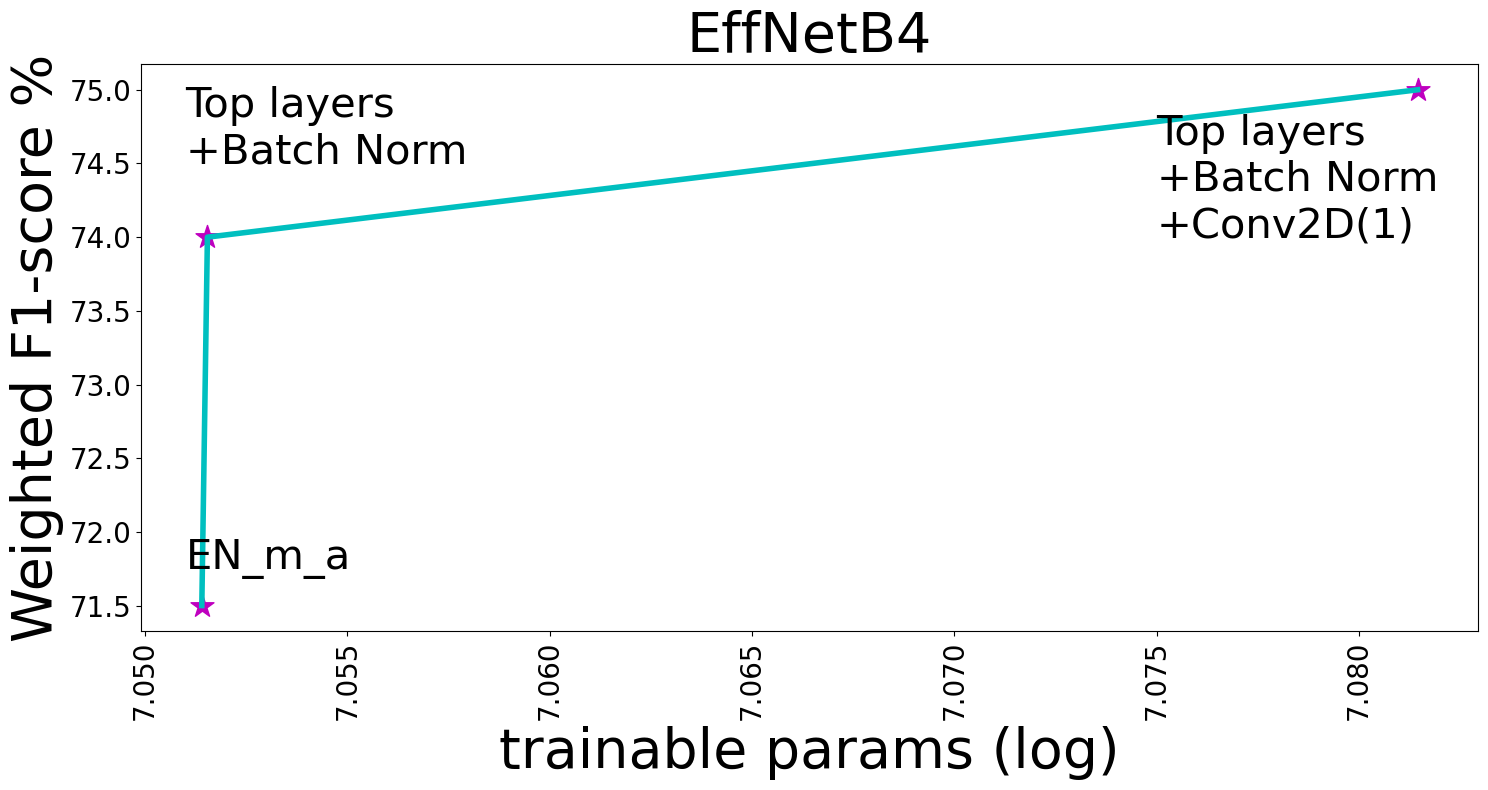

In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt


parameters  = np.array([11256451,11260035,12062851])
Weighted_F1_score = np.array([71.5,74,75])


plt.figure(figsize=(15,8))

print(len(parameters))
print(len(Weighted_F1_score))
plt.scatter(np.log10(parameters),Weighted_F1_score,marker='*',color='m',s=300)
from scipy.signal import savgol_filter
yhat = savgol_filter(Weighted_F1_score, 3,2) 
plt.plot(np.log10(parameters),yhat,'c',linewidth=4)
plt.xlabel('trainable params (log)',fontsize=40)
plt.ylabel('Weighted F1-score %',fontsize=40)
plt.xticks(rotation=90,fontsize=20)
plt.yticks(fontsize=20)
#yhat = savgol_filter(Weighted_F1_score, 11,10) 
#plt.plot(parameters,yhat,'y',linewidth=4)
#from scipy.interpolate import interp1d

np.array([71.5,74,75])
plt.title('EffNetB4',fontsize=40)
plt.text(7.051, 71.75, "EN_m_a", fontsize=30, color='black')
plt.text(7.051, 74.5, "Top layers\n+Batch Norm", fontsize=30, color='black')
plt.text(7.075, 74, "Top layers\n+Batch Norm\n+Conv2D(1)", fontsize=30, color='black')
plt.tight_layout()
#parameters  = np.array([3228291,5588098,5588099,7947907,7947908,11256451,11260035,11260036,12059267,12062851,12062852])
plt.savefig('ENB4_train_more_layers.png')


